https://github.com/aditis1204/Hypespectral_Visualization_Classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd "/content/drive/MyDrive/Bsc Thesis/Seminar 2 code/Dataset"

/content/drive/MyDrive/Bsc Thesis/Seminar 2 code/Dataset


### Downloading Indian pines hyperspecral dataset:

In [ ]:
!wget "http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat"


!wget "http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat"
!wget "http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat"

--2023-06-10 16:27:49--  http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat
Resolving www.ehu.eus (www.ehu.eus)... 158.227.0.65, 2001:720:1410::65
Connecting to www.ehu.eus (www.ehu.eus)|158.227.0.65|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat [following]
--2023-06-10 16:27:49--  https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat
Connecting to www.ehu.eus (www.ehu.eus)|158.227.0.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5953527 (5.7M)
Saving to: ‘Indian_pines_corrected.mat.6’

Indian_pines_correc 100%[===================>]   5.68M  2.36MB/s    in 2.4s    

2023-06-10 16:27:52 (2.36 MB/s) - ‘Indian_pines_corrected.mat.6’ saved [5953527/5953527]

URL transformed to HTTPS due to an HSTS policy
--2023-06-10 16:27:52--  https://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat
Resolving www.ehu.eus (www.e

### Useful imports

In [ ]:
!pip install spectral
!pip install patchify

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for spectral: filename=spectral-0.25-py3-none-any.whl size=242858 sha256=93cd07752140366cd7b52fe075730136860eae386cdab1e0fe5e6f3a762a8e02
  Stored in directory: /root/.cache/pip/wheels/f2/7e/b4/fa29a628ef6a4379f8ff6b1ee8c057b06fa343173404723749
Successfully built spectral


In [ ]:
!pip install "tensorflow==2.15.0" "keras==2.15.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully un

In [ ]:
import keras
from tensorflow.keras.layers import Conv2D, Conv3D, Flatten, Dense, Reshape, BatchNormalization,Add,Activation
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from keras.layers import Dropout, Input
from tensorflow.keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

from operator import truediv

from plotly.offline import init_notebook_mode

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.io as sio
import os

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, ReLU, Input, Concatenate
from scipy.spatial.distance import cdist
from tqdm import tqdm
import pandas as pd

## Importing Library.
from scipy.io import loadmat,savemat

import math

import spectral


# np.random.seed(1024)
tf.random.set_seed(2)


In [ ]:
!ls


Dataset_test.csv	   Dataset_train_map.csv       my_model.h5
Dataset_test_indexed.csv   Indian_pines_corrected.mat  my_model_old.h5
Dataset_test_map.csv	   Indian_pines_gt.mat	       result.docx
Dataset_train.csv	   IP_false_color_img.png
Dataset_train_indexed.csv  IP_gt_png.png


In [ ]:
import os
for dirname, _,filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:

dataset = loadmat('Indian_pines_corrected.mat')['indian_pines_corrected']
ground_truth = loadmat('Indian_pines_gt.mat')['indian_pines_gt']

In [ ]:

# #The dimensions of the data.
# print(f'Dataset: {dataset.shape}\nGround Truth: {ground_truth.shape}')
# #print(f'Dataset1: {dataset1.shape}\nGround Truth1: {ground_truth1.shape}')

# False color image

/usr/local/lib/python3.10/dist-packages/spectral/graphics/spypylab.py:796: UserWarning:

Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.



(-0.5, 144.5, 144.5, -0.5)

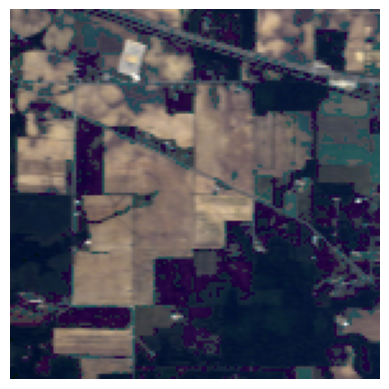

In [ ]:
spectral.imshow(dataset, (29, 19, 9))
plt.axis('off')
# plt.savefig('IP_false_color_img.png',bbox_inches='tight')

# Data visualization:

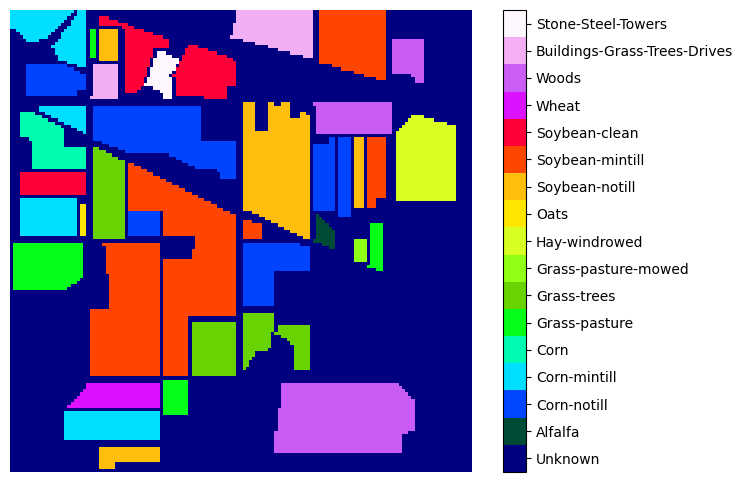

In [ ]:

plt.figure(figsize=(8, 6))
# cmap='nipy_spectral'
cmap = plt.get_cmap('gist_ncar', 17)
plt.imshow(ground_truth, cmap=cmap,vmin=np.min(ground_truth) - 0.5,vmax=np.max(ground_truth) + 0.5)   #cmap='gist_ncar'
# spectral.imshow(classes=ground_truth)
# plt.imshow(ground_truth, cmap='nipy_spectral')
plt.axis('off')
cbar=plt.colorbar(ticks= range(0,17))
class_labels = [
    'Unknown', 'Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn',
    'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed',
    'Oats', 'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat',
    'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers'
]
cbar.ax.set_yticklabels(class_labels)
plt.savefig('IP_gt_png.png',bbox_inches='tight')
# spectral.save_rgb('gt.jpg', ground_truth, colors=spectral.spy_colors)
plt.show()

In [ ]:
# testing horizontal

def ho_ar(hsi_cube, gt_map):
    s= hsi_cube.shape[0]
    d=hsi_cube.shape[2]
    hsi_cube = np.reshape(hsi_cube,(s*s,d))
    gt_map = np.reshape(gt_map,(s*s))


    new_cube = np.zeros((s*s,d))
    new_map = np.zeros((s*s))

    uniq,indices=np.unique(gt_map,return_index = True)
    indices=np.unique(indices)
    idx = 0
    for indice in indices:
        label = gt_map[indice]
        for i in range(gt_map.shape[0]):
            if label == gt_map[i]:
                new_cube[idx,:] = hsi_cube[i,:]
                new_map[idx] = gt_map[i]
                idx+=1

    new_cube = np.reshape(new_cube,(s,s,d))
    new_map = np.reshape(new_map,(s,s))
    return new_cube, new_map

# dataset, ground_truth=ho_ar(dataset, ground_truth)

# plt.figure(figsize=(8, 6))
# plt.imshow(ground_truth, cmap='gist_ncar')
# # plt.imshow(ground_truth, cmap='nipy_spectral')
# plt.axis('off')
# plt.colorbar(ticks= range(0,17))
# plt.show()

### Extracting Band Information:

In [ ]:

def extract_pixels(dataset, ground_truth):
    df = pd.DataFrame()
    # for i in tqdm(range(dataset.shape[2])):
    for i in (range(dataset.shape[2])):
        df = pd.concat([df, pd.DataFrame(dataset[:, :, i].ravel())], axis=1)
    df = pd.concat([df, pd.DataFrame(ground_truth.ravel())], axis=1)
    df.columns = [f'band-{i}' for i in range(1, 1+dataset.shape[2])]+['class']
    return df

In [ ]:
df = extract_pixels(dataset, ground_truth)
df.head()

,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-192,band-193,band-194,band-195,band-196,band-197,band-198,band-199,band-200,class
0,3172,4142,4506,4279,4782,5048,5213,5106,5053,4750,...,1094,1090,1112,1090,1062,1069,1057,1020,1020,3
1,2580,4266,4502,4426,4853,5249,5352,5353,5347,5065,...,1108,1104,1117,1091,1079,1085,1064,1029,1020,3
2,3687,4266,4421,4498,5019,5293,5438,5427,5383,5132,...,1111,1114,1114,1100,1065,1092,1061,1030,1016,3
3,2749,4258,4603,4493,4958,5234,5417,5355,5349,5096,...,1122,1108,1109,1109,1071,1088,1060,1030,1006,3
4,2746,4018,4675,4417,4886,5117,5215,5096,5098,4834,...,1110,1107,1112,1094,1072,1087,1052,1034,1019,3


In [ ]:
df

,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-192,band-193,band-194,band-195,band-196,band-197,band-198,band-199,band-200,class
0,3172,4142,4506,4279,4782,5048,5213,5106,5053,4750,...,1094,1090,1112,1090,1062,1069,1057,1020,1020,3
1,2580,4266,4502,4426,4853,5249,5352,5353,5347,5065,...,1108,1104,1117,1091,1079,1085,1064,1029,1020,3
2,3687,4266,4421,4498,5019,5293,5438,5427,5383,5132,...,1111,1114,1114,1100,1065,1092,1061,1030,1016,3
3,2749,4258,4603,4493,4958,5234,5417,5355,5349,5096,...,1122,1108,1109,1109,1071,1088,1060,1030,1006,3
4,2746,4018,4675,4417,4886,5117,5215,5096,5098,4834,...,1110,1107,1112,1094,1072,1087,1052,1034,1019,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21020,2561,3987,4011,4023,4201,4377,4418,4248,4180,3838,...,1013,1012,1018,1015,1011,1001,1000,1009,1008,0
21021,2726,4104,4024,3880,4210,4377,4413,4174,4229,3900,...,1012,1014,1012,1024,998,1010,1006,1000,1000,0
21022,3153,3864,4282,3889,4310,4372,4375,4208,4096,3878,...,1016,1015,1016,1021,1008,1019,1003,1008,1000,0
21023,3155,4104,4106,4027,4139,4318,4413,4174,4140,3933,...,1005,1011,1008,1012,1014,1007,1011,1005,1003,0


In [ ]:
print(df["class"].unique())
print(df["class"].unique())

[ 3  0 15 11 12  5 10 14 16  2  4  8  6  9  1  7 13]
[ 3  0 15 11 12  5 10 14 16  2  4  8  6  9  1  7 13]


In [ ]:
df = df.loc[df["class"] > 0]

In [ ]:
# df.to_csv('Dataset.csv', index=False)

### spliting:

In [ ]:
#train and test
# from sklearn.model_selection import train_test_split
# train, test = train_test_split(df, stratify=df[["class"]],test_size=0.90)

# train.loc[:, 'class'].value_counts()

In [ ]:
# test.loc[:, 'class'].value_counts()

In [ ]:
# train=train.sort_index()

# test=test.sort_index()
# train.to_csv('Dataset_train.csv', index=False)
# test.to_csv('Dataset_test.csv', index=False)


In [ ]:
# train.head()

In [ ]:
# test.head()

### Implemetation of Dimensionality reduction using truncated SVD

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# !pip install seaborn
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import train_test_split

In [ ]:
# df = pd.read_csv('Dataset.csv')
# df

In [ ]:
# X = df.iloc[:, :-1].values

# y = df.iloc[:, -1].values



# Load train and test dataset

In [ ]:
# train = pd.read_csv('/kaggle/input/hsicv4/Dataset_train.csv')
# test = pd.read_csv('/kaggle/input/hsicv4/Dataset_test.csv')

# train_idx = pd.read_csv('/kaggle/input/hsicv4/Dataset_train_indexed.csv')
# test_idx = pd.read_csv('/kaggle/input/hsicv4/Dataset_test_indexed.csv')

# train_map = pd.read_csv('/kaggle/input/hsicv4/Dataset_train_map.csv')
# test_map = pd.read_csv('/kaggle/input/hsicv4/Dataset_test_map.csv')

# # train = pd.read_csv('./Dataset_train.csv')
# # test = pd.read_csv('./Dataset_test.csv')

# X = train.iloc[:, :-1].values

# y = train.iloc[:, -1].values

In [ ]:
train = pd.read_csv('Dataset_train.csv')
test = pd.read_csv('Dataset_test.csv')

train_idx = pd.read_csv('Dataset_train_indexed.csv')
test_idx = pd.read_csv('Dataset_test_indexed.csv')

train_map = pd.read_csv('Dataset_train_map.csv')
test_map = pd.read_csv('Dataset_test_map.csv')

# train = pd.read_csv('./Dataset_train.csv')
# test = pd.read_csv('./Dataset_test.csv')

X = train.iloc[:, :-1].values

y = train.iloc[:, -1].values

In [ ]:
X.shape, y.shape
# print(y[100])

((1024, 200), (1024,))

In [ ]:
# test = pd.read_csv('./Dataset_test.csv')

In [ ]:
# y_pred = svm.predict(X_test)

## Accuracy and confusion mat

In [ ]:

# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# print(f'Accuracy: {accuracy_score(y_test, y_pred)*100}%')


In [ ]:

# ! pip install -q scikit-plot

# import scikitplot as skplt

# skplt.metrics.plot_confusion_matrix(
#     y_test,
#     y_pred,
#     figsize=(12,12));

In [ ]:
# print(confusion_matrix(y_test,y_pred))
# print('Classification report:\n',classification_report(y_test,y_pred))

In [ ]:

# plt.figure(figsize=(8, 6))
# plt.imshow(df.iloc[:, -1].values.reshape((145, 145)))
# plt.colorbar()
# plt.axis('off')
# plt.title('Ground Truth')
# plt.savefig('ground_truth.png')
# plt.show()

In [ ]:
# # !pip install tqdm
# from tqdm import tqdm
# pre = y_pred

# clmap = [0]*X.shape[0]

# for i in tqdm(range(len(indices_train))):
#     clmap[indices_train[i]] = y[indices_train[i]]

# for i in tqdm(range(len(indices_test))):
#     clmap[indices_test[i]] = pre[i]

In [ ]:
# plt.figure(figsize=(8, 6))
# plt.imshow(np.array(clmap).reshape((32, 32)))
# plt.colorbar()
# plt.axis('off')
# plt.title('Classification Map (PCA + SVM)')
# plt.savefig('Classification_map.png')
# plt.show()

In [ ]:
# # x=np.where([True, False,True, True])[0]
# # x
# aa_milne_arr = ['pooh', 'rabbit', 'piglet', 'Christopher']
# np.random.choice(aa_milne_arr, 4, replace=False)

In [ ]:
#v4
#latest

def generate_hsi_cube(x_train, y_train, M, s):
    # Reshape the data into a 3D array
#     np.random.seed(1024)
    n_pixels = x_train.shape[0]
    n_bands = x_train.shape[1]
    cube_shape = (s, s, n_bands)
    hsi_cube = np.zeros(cube_shape)
    gt_map = np.zeros((s, s))
    x_train_select = x_train

    # Randomly select M_c land-cover categories
    M_c = np.random.randint(1, M)
    class_labels = np.unique(y_train)
    selected_labels = np.random.choice(class_labels, M_c, replace=False)
    # print(class_labels)
    # print(selected_labels)

    # Generate the HSI cube

    cube = np.zeros((s*s,n_bands))
    gt = np.zeros(s*s)
    total_pixel_per_label = np.zeros(selected_labels.size)
    list_pixel_indices=[]

    for i, label in enumerate(selected_labels):
        pixel_indices = np.where(y_train == label)[0]
        total_pixel_per_label[i]= pixel_indices.size
        list_pixel_indices.append(pixel_indices)

    for i, label in enumerate(selected_labels):
        selected_pixels = np.random.choice(list_pixel_indices[i], 1, replace=False)
        total_pixel_per_label[i]-=1
        cube[i]= x_train[selected_pixels]
        gt[i]=label

    k= selected_labels.size
    for i in range(s*s-k):
        label = np.random.choice(selected_labels, 1, replace=False)
        label_idx = np.where(selected_labels == label)[0][0]
        # print(label_idx)
        if(total_pixel_per_label[label_idx]<=0):
            vs_px_idx=np.random.choice(list_pixel_indices[label_idx], 1, replace=False)
            vs_px_jdx=np.random.choice(list_pixel_indices[label_idx], 1, replace=False)
            # distances = cdist(x_train[vs_px_idx], x_train[vs_px_jdx], metric='euclidean')
            distances = np.linalg.norm(x_train[vs_px_idx]-x_train[vs_px_jdx])
            Aij = np.exp(-1 * (distances ** 2) / 2)
            mix = (1-Aij)*x_train[vs_px_idx]+Aij*x_train[vs_px_jdx]
            cube[i+k]= mix
            gt[i+k]=label
            # raise ValueError("Not enough samples in selected label to generate virtual samples")
        else:
            selected_pixels = np.random.choice(list_pixel_indices[label_idx], 1, replace=False)
            total_pixel_per_label[label_idx]-=1
            cube[i+k]= x_train[selected_pixels]
            gt[i+k]=label

    hsi_cube = np.reshape(cube,(s,s,n_bands))
    gt_map = np.reshape(gt,(s,s))

    # # Generate the HSI cube
    # for i, label in enumerate(selected_labels):
    #     pixel_indices = np.where(y_train == label)[0]
    #     selected_pixels = np.random.choice(pixel_indices, s**2, replace=True)
    #     for j, idx in enumerate(selected_pixels):
    #         x = x_train[idx, :]
    #         row = j // s
    #         col = j % s
    #         hsi_cube[row, col, :] = x
    #         gt_map[row, col] = i
    # df = extract_pixels(hsi_cube, gt_map)
    # df=df.sample(frac=1)
    # hsi_cube = df.iloc[:, :-1].values

    # gt_map = df.iloc[:, -1].values

    # hsi_cube = np.reshape(hsi_cube,(s,s,n_bands))
    # gt_map = np.reshape(gt_map,(s,s))

    return hsi_cube, gt_map

In [ ]:
def hozrizontal_arrange(hsi_cube,gt_map):

    s= hsi_cube.shape[0]
    d=hsi_cube.shape[2]
    hsi_cube = np.reshape(hsi_cube,(s*s,d))
    gt_map = np.reshape(gt_map,(s*s))


    new_cube = np.zeros((s*s,d))
    new_map = np.zeros((s*s))

    uniq,indices=np.unique(gt_map,return_index = True)
    indices=np.unique(indices)
    idx = 0
    for indice in indices:
        label = gt_map[indice]
        for i in range(gt_map.shape[0]):
            if label == gt_map[i]:
                new_cube[idx,:] = hsi_cube[i,:]
                new_map[idx] = gt_map[i]
                idx+=1

    new_cube = np.reshape(new_cube,(s,s,d))
    new_map = np.reshape(new_map,(s,s))
    return new_cube, new_map

/usr/local/lib/python3.10/dist-packages/spectral/graphics/spypylab.py:796: UserWarning:

Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.



[[12. 10.  5.  5. 12. 10. 12.]
 [12.  5. 10.  5.  5.  5. 10.]
 [ 5. 10. 12. 10. 10. 10. 10.]
 [10. 10.  5. 10. 10.  5.  5.]
 [12.  5.  5.  5. 12. 10.  5.]
 [10. 10. 10.  5. 10. 12. 10.]
 [ 5. 10. 12. 12. 10.  5.  5.]]


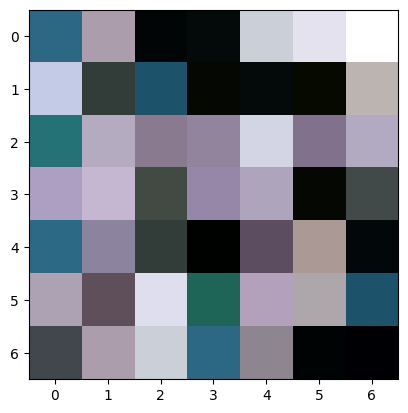

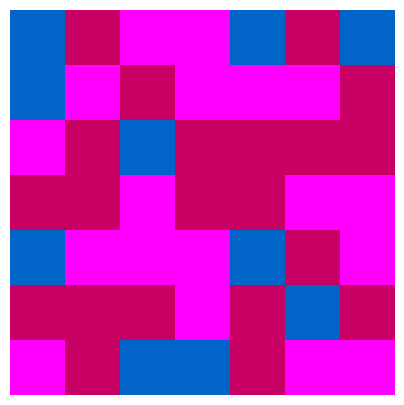

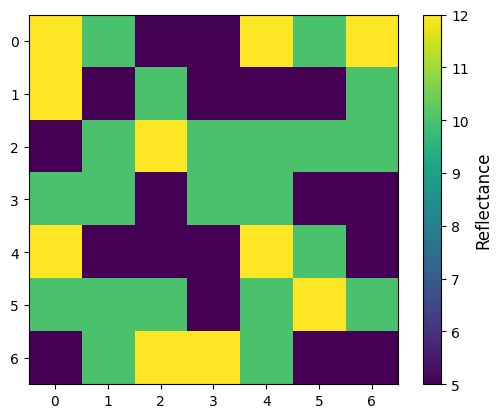

In [ ]:

X_train, y_train, X_test,  y_test = train.iloc[:, :-1].values, train.iloc[:, -1].values, test.iloc[:, :-1].values, test.iloc[:, -1].values
hsi_cube, gt_map = generate_hsi_cube(X_train, y_train, M=9, s=7)


# Display the HSI cube and ground-truth map using spectral library
spectral.imshow(hsi_cube, (29, 19, 9))
spectral.imshow(classes=gt_map.astype(int), figsize=(5, 5))
# plt.colorbar()
plt.axis('off')

# Display HSI cube with colorbar
fig, ax = plt.subplots()
im = ax.imshow(gt_map)
cbar = plt.colorbar(im)
cbar.ax.set_ylabel('Reflectance', fontsize=12)

print(gt_map)

In [ ]:
# def hozrizontal_arrange(hsi_cube,gt_map):

#     df = extract_pixels(hsi_cube, gt_map)
#     df=df.sort_values(by=['class'])

#     # df.head()




#     arng_cube = df.iloc[:, :-1].values

#     arng_gt_map = df.iloc[:, -1].values

#     arng_cube=np.reshape(arng_cube, (7, 7,200))
#     arng_gt_map=np.reshape(arng_gt_map, (7, 7))

#     # Display the HSI cube and ground-truth map using spectral library
#     # spectral.imshow(arng_cube, (29, 19, 9))
#     # spectral.imshow(classes=arng_gt_map.astype(int), figsize=(5, 5))
#     # # plt.colorbar()
#     # plt.axis("off")

#     # # Display HSI cube with colorbar
#     # fig, ax = plt.subplots()
#     # im = ax.imshow(arng_gt_map)
#     # cbar = plt.colorbar(im)
#     # cbar.ax.set_ylabel('Reflectance', fontsize=12)

#     return arng_cube, arng_gt_map

In [ ]:


def zigzag_rearrange(hsi_cube, gt_map):

    #     df = extract_pixels(cube, gt)
#     df=df.sort_values(by=['class'])
#     data_arng_cube = df.iloc[:, :-1].values

#     data_arng_gt_map = df.iloc[:, -1].values

    s= hsi_cube.shape[0]
    d=hsi_cube.shape[2]
    hsi_cube = np.reshape(hsi_cube,(s*s,d))
    gt_map = np.reshape(gt_map,(s*s))


    new_cube = np.zeros((s*s,d))
    new_map = np.zeros((s*s))

    uniq,indices=np.unique(gt_map,return_index = True)
    indices=np.unique(indices)
    idx = 0
    for indice in indices:
        label = gt_map[indice]
        for i in range(gt_map.shape[0]):
            if label == gt_map[i]:
                new_cube[idx,:] = hsi_cube[i,:]
                new_map[idx] = gt_map[i]
                idx+=1




    data_arng_cube = new_cube

    data_arng_gt_map = new_map
    cube_zigzag=np.zeros((7, 7,200))
    gt_zigzag=np.zeros((7, 7))

    """
    Rearrange the pixels in a hyperspectral image cube and ground truth
    in a zigzag order.

    Parameters:
    cube (numpy.ndarray): Hyperspectral image cube with shape (rows, cols, bands).
    gt (numpy.ndarray): Ground truth image with shape (rows, cols).

    Returns:
    numpy.ndarray: The rearranged hyperspectral image cube with shape (rows*cols, bands).
    numpy.ndarray: The rearranged ground truth image with shape (rows*cols,).
    """
    # Get the dimensions of the input images
    rows, cols, bands = s,s,d
     # Set up the zigzag pattern
    zigzag = np.array([
        [0, 1, 5, 6, 14, 15, 27],
        [2, 4, 7, 13, 16, 26, 28],
        [3, 8, 12, 17, 25, 29, 38],
        [9, 11, 18, 24, 30, 37, 39],
        [10, 19, 23, 31, 36, 40, 45],
        [20, 22, 32, 35, 41, 44, 46],
        [21, 33, 34, 42, 43, 47, 48],
    ])

    # Rearrange the pixels in the zigzag order
    # for i in range(bands):
    #     band = cube[:, :, i]
    #     for r in range(0, rows, 7):
    #         for c in range(0, cols, 7):
    #             block = band[r:r+7, c:c+7]
    #             block_zigzag = block[zigzag.flatten()]
    #             idx = (r // 7) * (cols // 7) * 49 + (c // 7) * 49 + i * 49
    #             cube_zigzag[idx:idx+49, i] = block_zigzag

    # Rearrange the ground truth labels in the same order
    for r in range(0, rows):
        for c in range(0, cols):
            gt_zigzag[r,c] = data_arng_gt_map[zigzag[r,c]]
            cube_zigzag[r,c, :] = data_arng_cube[zigzag[r,c],:]

#     cube_zigzag=np.reshape(cube_zigzag, (7, 7,200))
#     gt_zigzag=np.reshape(gt_zigzag, (7, 7))
    return cube_zigzag, gt_zigzag




/tmp/ipython-input-7-1511041894.py:58: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/tmp/ipython-input-7-1511041894.py:52: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



(1024, 200)


100%|██████████| 10000/10000 [00:23<00:00, 423.10it/s]


[[15.  6.  3.  8.  7.  2.  3.]
 [ 8.  8.  2.  3.  6.  2.  7.]
 [ 6.  2.  2.  6.  7.  2.  8.]
 [ 7. 15.  3.  8.  7.  6.  6.]
 [ 2.  3.  3.  6.  6.  6. 15.]
 [15.  3. 15. 15.  7.  6.  6.]
 [ 7.  2.  6.  3.  8. 15.  2.]]


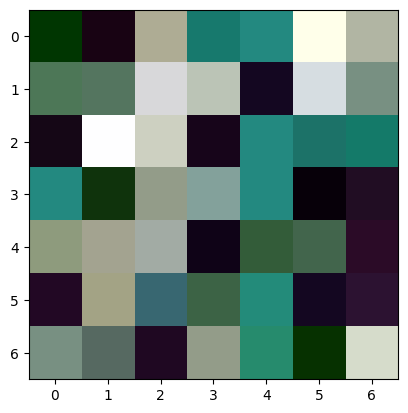

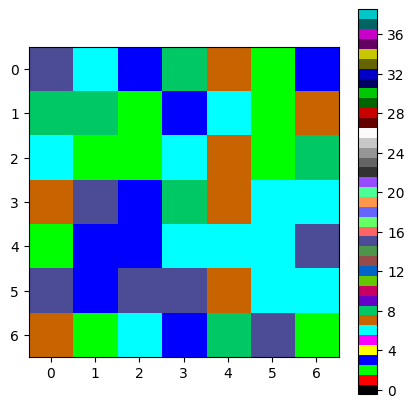

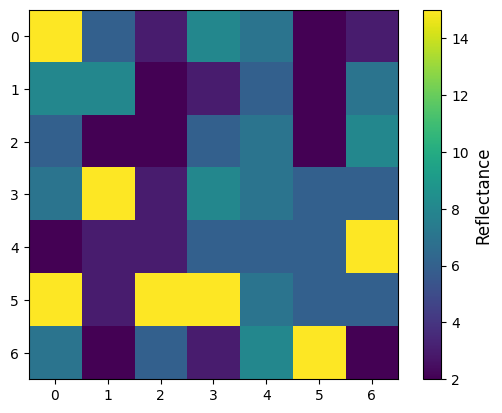

In [ ]:

# tf.random.set_seed(2)

from sklearn.datasets import fetch_openml
import numpy as np
import spectral
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

np.random.seed(1024)

# Import the Indian Pines dataset
# indian_pines = fetch_openml(name='Indian_pines')

# Get the data and corresponding labels
# X = indian_pines.data
# y = indian_pines.target

# X = dataset.ravel()
# y = ground_truth.ravel()

# Preprocess the data
# X = X.astype(float)
# X /= np.max(X)

# Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y)

X_train, y_train, X_test,  y_test = train.iloc[:, :-1].values, train.iloc[:, -1].values, test.iloc[:, :-1].values, test.iloc[:, -1].values


# Encode the class labels
# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_test = le.transform(y_test)

print(X_train.shape)




# Apply the generate_hsi_cube function with sample=5
sample=10000

hsi_cube, gt_map = generate_hsi_cube(X_train, y_train, M=16, s=7)
cube_samples = np.zeros((sample, 7, 7, 200))
gt_samples = np.zeros((sample, 7, 7))
for i in tqdm(range(int(sample))):
    hsi_cube, gt_map = generate_hsi_cube(X_train, y_train, M=11, s=7)
#     hsi_cube, gt_map = hozrizontal_arrange(hsi_cube, gt_map)
    cube_samples[i,:,:,:] = hsi_cube[:,:,:]
    gt_samples[i,:,:] = gt_map[:,:]
# Display the HSI cube and ground-truth map using spectral library
spectral.imshow(hsi_cube, (29, 19, 9))
spectral.imshow(classes=gt_map.astype(int), figsize=(5, 5))
plt.colorbar()

# Display HSI cube with colorbar
fig, ax = plt.subplots()
im = ax.imshow(gt_map)
cbar = plt.colorbar(im)
cbar.ax.set_ylabel('Reflectance', fontsize=12)

print(gt_map)

100%|██████████| 10000/10000 [00:06<00:00, 1548.59it/s]


Text(0, 0.5, 'Reflectance')

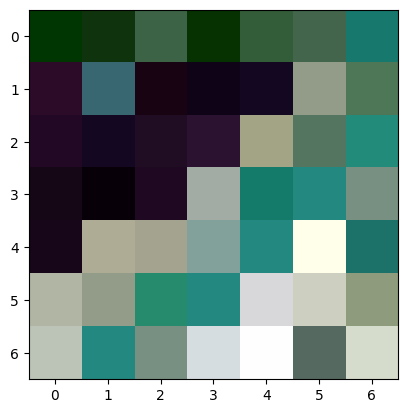

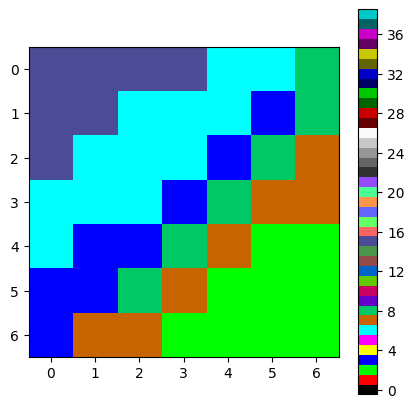

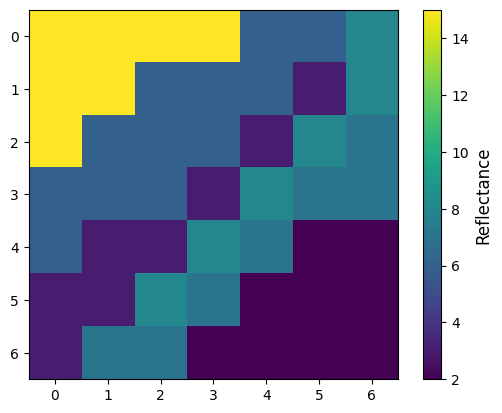

In [ ]:
aug_num=6
hor_cube_samples = np.zeros((aug_num*sample, 7, 7, 200))
hor_gt_samples = np.zeros((aug_num*sample, 7, 7))
for i in tqdm(range(int(sample))):
#     hsi_cube, gt_map = generate_hsi_cube(X_train, y_train, M=7, s=7)
    if(i%2==0):
        hsi_cube, gt_map = hozrizontal_arrange(cube_samples[i], gt_samples[i])
    if(i%2==1):
        hsi_cube, gt_map=zigzag_rearrange(cube_samples[i], gt_samples[i])
#     hsi_cube, gt_map=(cube_samples[i], gt_samples[i])
    hor_cube_samples[i*aug_num,:,:,:] = hsi_cube[:,:,:]
    hor_gt_samples[i*aug_num,:,:] = gt_map[:,:]

#     fliplr
    hor_cube_samples[i*aug_num+1,:,:,:] = np.fliplr(hsi_cube)[:,:,:]
    hor_gt_samples[i*aug_num+1,:,:] = np.fliplr(gt_map)[:,:]

    #     fliplr
    hor_cube_samples[i*aug_num+2,:,:,:] = np.flipud(hsi_cube)[:,:,:]
    hor_gt_samples[i*aug_num+2,:,:] = np.flipud(gt_map)[:,:]

    #     rotate 90
    hor_cube_samples[i*aug_num+3,:,:,:] = np.rot90(hsi_cube)[:,:,:]
    hor_gt_samples[i*aug_num+3,:,:] = np.rot90(gt_map)[:,:]

    #     rotate 180
    hor_cube_samples[i*aug_num+4,:,:,:] = np.rot90(hsi_cube,2)[:,:,:]
    hor_gt_samples[i*aug_num+4,:,:] = np.rot90(gt_map,2)[:,:]

    #     rotate 270
    hor_cube_samples[i*aug_num+5,:,:,:] = np.rot90(hsi_cube,3)[:,:,:]
    hor_gt_samples[i*aug_num+5,:,:] = np.rot90(gt_map,3)[:,:]

# Display the HSI cube and ground-truth map using spectral library
spectral.imshow(hsi_cube, (29, 19, 9))
spectral.imshow(classes=gt_map.astype(int), figsize=(5, 5))
plt.colorbar()

# Display HSI cube with colorbar
fig, ax = plt.subplots()
im = ax.imshow(gt_map)
cbar = plt.colorbar(im)
cbar.ax.set_ylabel('Reflectance', fontsize=12)

In [ ]:
df = extract_pixels(hsi_cube, gt_map)

df.head()



,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-192,band-193,band-194,band-195,band-196,band-197,band-198,band-199,band-200,class
0,3166.0,3769.0,3952.0,3815.0,4158.0,4281.0,4298.0,4186.0,4174.0,3837.0,...,1021.0,1028.0,1023.0,1020.0,1019.0,1011.0,1007.0,1010.0,1000.0,15.0
1,2570.0,3882.0,3954.0,3822.0,4166.0,4394.0,4399.0,4286.0,4124.0,3906.0,...,1024.0,1027.0,1019.0,1016.0,1023.0,1006.0,1008.0,1000.0,1010.0,15.0
2,2571.0,4137.0,4138.0,4041.0,4456.0,4786.0,4776.0,4710.0,4539.0,4286.0,...,1045.0,1050.0,1048.0,1039.0,1038.0,1027.0,1023.0,1020.0,1005.0,15.0
3,2998.0,4005.0,4045.0,3819.0,4154.0,4379.0,4336.0,4169.0,4096.0,3825.0,...,1031.0,1025.0,1022.0,1020.0,1017.0,1019.0,1009.0,1010.0,1010.0,15.0
4,2589.0,3995.0,4137.0,4037.0,4402.0,4598.0,4627.0,4503.0,4409.0,4203.0,...,1048.0,1049.0,1057.0,1050.0,1027.0,1025.0,1020.0,1014.0,1004.0,6.0


In [ ]:
df

,band-1,band-2,band-3,band-4,band-5,band-6,band-7,band-8,band-9,band-10,...,band-192,band-193,band-194,band-195,band-196,band-197,band-198,band-199,band-200,class
0,3166.0,3769.0,3952.0,3815.0,4158.0,4281.0,4298.0,4186.0,4174.0,3837.0,...,1021.0,1028.0,1023.0,1020.0,1019.0,1011.0,1007.0,1010.0,1000.0,15.0
1,2570.0,3882.0,3954.0,3822.0,4166.0,4394.0,4399.0,4286.0,4124.0,3906.0,...,1024.0,1027.0,1019.0,1016.0,1023.0,1006.0,1008.0,1000.0,1010.0,15.0
2,2571.0,4137.0,4138.0,4041.0,4456.0,4786.0,4776.0,4710.0,4539.0,4286.0,...,1045.0,1050.0,1048.0,1039.0,1038.0,1027.0,1023.0,1020.0,1005.0,15.0
3,2998.0,4005.0,4045.0,3819.0,4154.0,4379.0,4336.0,4169.0,4096.0,3825.0,...,1031.0,1025.0,1022.0,1020.0,1017.0,1019.0,1009.0,1010.0,1010.0,15.0
4,2589.0,3995.0,4137.0,4037.0,4402.0,4598.0,4627.0,4503.0,4409.0,4203.0,...,1048.0,1049.0,1057.0,1050.0,1027.0,1025.0,1020.0,1014.0,1004.0,6.0
5,2760.0,3986.0,4207.0,4106.0,4460.0,4696.0,4711.0,4606.0,4547.0,4329.0,...,1062.0,1062.0,1058.0,1040.0,1034.0,1056.0,1035.0,1010.0,1014.0,6.0
6,2592.0,4248.0,4401.0,4334.0,4577.0,4857.0,4915.0,4832.0,4767.0,4546.0,...,1065.0,1080.0,1071.0,1054.0,1038.0,1051.0,1035.0,1014.0,1004.0,8.0
7,2565.0,4131.0,4134.0,4106.0,4393.0,4541.0,4608.0,4443.0,4376.0,4084.0,...,1038.0,1033.0,1045.0,1033.0,1027.0,1026.0,1022.0,1019.0,1010.0,15.0
8,2723.0,4378.0,4413.0,4256.0,4675.0,5027.0,4998.0,4871.0,4812.0,4576.0,...,1033.0,1034.0,1042.0,1034.0,1030.0,1034.0,1021.0,1010.0,1006.0,15.0
9,3183.0,3857.0,4027.0,3894.0,4220.0,4481.0,4470.0,4263.0,4219.0,3956.0,...,1030.0,1028.0,1031.0,1021.0,1011.0,1023.0,1011.0,1004.0,1004.0,6.0


In [ ]:
# def hozrizontal_arrange(hsi_cube,gt_map):

#     df = extract_pixels(hsi_cube, gt_map)
#     df=df.sort_values(by=['class'])

#     # df.head()




#     arng_cube = df.iloc[:, :-1].values

#     arng_gt_map = df.iloc[:, -1].values

#     arng_cube=np.reshape(arng_cube, (7, 7,200))
#     arng_gt_map=np.reshape(arng_gt_map, (7, 7))

#     # Display the HSI cube and ground-truth map using spectral library
#     # spectral.imshow(arng_cube, (29, 19, 9))
#     # spectral.imshow(classes=arng_gt_map.astype(int), figsize=(5, 5))
#     # # plt.colorbar()
#     # plt.axis("off")

#     # # Display HSI cube with colorbar
#     # fig, ax = plt.subplots()
#     # im = ax.imshow(arng_gt_map)
#     # cbar = plt.colorbar(im)
#     # cbar.ax.set_ylabel('Reflectance', fontsize=12)

#     return arng_cube, arng_gt_map

In [ ]:


# def zigzag_rearrange(cube, gt):

#     df = extract_pixels(cube, gt)
#     df=df.sort_values(by=['class'])
#     data_arng_cube = df.iloc[:, :-1].values

#     data_arng_gt_map = df.iloc[:, -1].values

# #     data_arng_cube = cube.ravel()

# #     data_arng_gt_map = gt.ravel()
#     cube_zigzag=np.zeros((7, 7,200))
#     gt_zigzag=np.zeros((7, 7))

#     """
#     Rearrange the pixels in a hyperspectral image cube and ground truth
#     in a zigzag order.

#     Parameters:
#     cube (numpy.ndarray): Hyperspectral image cube with shape (rows, cols, bands).
#     gt (numpy.ndarray): Ground truth image with shape (rows, cols).

#     Returns:
#     numpy.ndarray: The rearranged hyperspectral image cube with shape (rows*cols, bands).
#     numpy.ndarray: The rearranged ground truth image with shape (rows*cols,).
#     """
#     # Get the dimensions of the input images
#     rows, cols, bands = cube_zigzag.shape
#      # Set up the zigzag pattern
#     zigzag = np.array([
#         [0, 1, 5, 6, 14, 15, 27],
#         [2, 4, 7, 13, 16, 26, 28],
#         [3, 8, 12, 17, 25, 29, 38],
#         [9, 11, 18, 24, 30, 37, 39],
#         [10, 19, 23, 31, 36, 40, 45],
#         [20, 22, 32, 35, 41, 44, 46],
#         [21, 33, 34, 42, 43, 47, 48],
#     ])

#     # Rearrange the pixels in the zigzag order
#     # for i in range(bands):
#     #     band = cube[:, :, i]
#     #     for r in range(0, rows, 7):
#     #         for c in range(0, cols, 7):
#     #             block = band[r:r+7, c:c+7]
#     #             block_zigzag = block[zigzag.flatten()]
#     #             idx = (r // 7) * (cols // 7) * 49 + (c // 7) * 49 + i * 49
#     #             cube_zigzag[idx:idx+49, i] = block_zigzag

#     # Rearrange the ground truth labels in the same order
#     for r in range(0, rows):
#         for c in range(0, cols):
#             gt_zigzag[r,c] = data_arng_gt_map[zigzag[r,c]]
#             cube_zigzag[r,c, :] = data_arng_cube[zigzag[r,c]]

#     cube_zigzag=np.reshape(cube_zigzag, (7, 7,200))
#     gt_zigzag=np.reshape(gt_zigzag, (7, 7))
#     return cube_zigzag, gt_zigzag




[[15. 15. 15. 15.  6.  6.  3.]
 [15. 15.  6.  6.  6.  3.  3.]
 [15.  6.  6.  6.  3.  3.  7.]
 [ 6.  6.  6.  8.  3.  7.  7.]
 [ 6.  8.  8.  3.  7.  2.  2.]
 [ 8.  8.  3.  7.  2.  2.  2.]
 [ 8.  7.  7.  2.  2.  2.  2.]]


/usr/local/lib/python3.10/dist-packages/spectral/graphics/spypylab.py:796: UserWarning:

Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.



Text(0, 0.5, 'Reflectance')

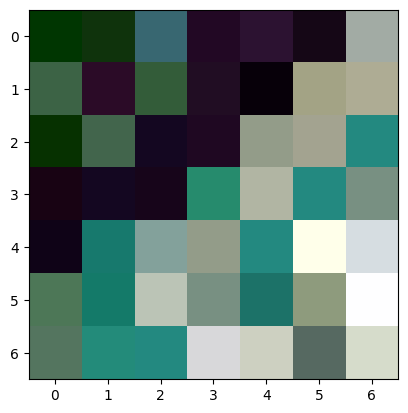

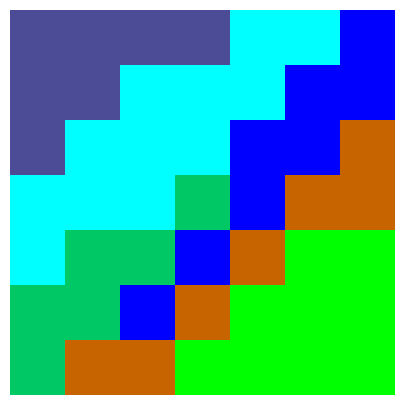

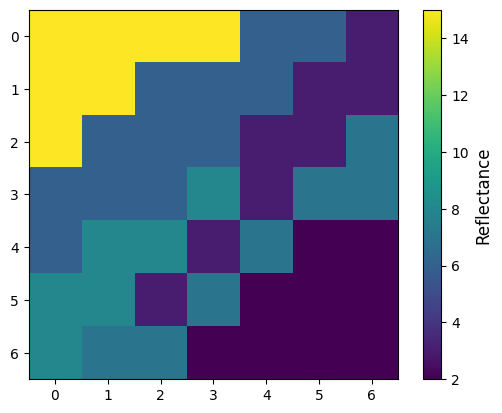

In [ ]:
# arng_cube, arng_gt_map = ()

cube_zigzag, gt_zigzag=zigzag_rearrange(hsi_cube, gt_map)

# Display the HSI cube and ground-truth map using spectral library
print(gt_zigzag)
spectral.imshow(cube_zigzag, (29, 19, 9))
spectral.imshow(classes=gt_zigzag.astype(int), figsize=(5, 5))
# plt.colorbar()
plt.axis("off")

# Display HSI cube with colorbar
fig, ax = plt.subplots()
im = ax.imshow(gt_zigzag)
cbar = plt.colorbar(im)
cbar.ax.set_ylabel('Reflectance', fontsize=12)

In [ ]:
def residual_block(Xin,f=3, kernel_num=64,training=True, initializer=random_uniform):
    # Shortcut path
    X_shortcut = Xin

    # Main path
    X = Conv2D(kernel_num, (3, 3), strides=(1, 1), padding='same',kernel_initializer = initializer(seed=0))(Xin)
    X = BatchNormalization(axis=3)(X, training = training)
    X = Activation('relu')(X)

    X = Conv2D(kernel_num, (3, 3), strides=(1, 1), padding='same',kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis=3)(X, training = training)

    # Adding shortcut to main path
    X = Add()([X,X_shortcut])
    X = Activation('relu')(X)

    return X


In [ ]:
def build_model(input_shape, num_classes=16, kernel_num=64, num_residual_blocks=5):
    inputs = Input(shape=input_shape)

    # Step 1: First convolutional layer
#     x = Conv2D(kernel_num, kernel_size=(3, 3), padding='same', activation='relu')(inputs)
    X = Conv2D(kernel_num, (3, 3), strides=(1, 1), padding='same',kernel_initializer = glorot_uniform(seed=0))(inputs)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)

    # Step 2: Residual blocks 5
#     for i in range(num_residual_blocks):
#         x = residual_block(x, kernel_num)

    X = residual_block(X, 3, 64)
    X = residual_block(X, 3, 64)
    X = residual_block(X, 3, 64)
    X = residual_block(X, 3, 64)
    X = residual_block(X, 3, 64)

    # Step 3: Second convolutional layer
#     x = Conv2D(num_classes, kernel_size=(3, 3), padding='same')(x)
#     x = BatchNormalization()(x)
#     x = ReLU()(x)

    # Step 4: Output layer
    X = Conv2D(num_classes, kernel_size=(1, 1), padding='same')(X)
#     outputs=Activation('softmax', axis=3)(X)
    outputs = tf.nn.softmax(X,axis=int(3))

    # Define the model
    model = Model(inputs=inputs, outputs=outputs)

    return model

In [ ]:
# from tensorflow.keras.optimizers import Adam

# def train_model(model, X_train, y_train, X_val, y_val, optimizer,epochs, batch_size):
#     # optimizer = Adam(lr=1e-4)
#     model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
#     history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size)
#     return history


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from keras.models import load_model

# Load the trained FCSN model
# model = load_model('fcsn_model.h5')

# Load the HSI cube and ground truth map
# hsi_cube = np.load('hsi_cube.npy')
# gt_map = np.load('gt_map.npy')

# Calculate the number of rows to be added

# Calculate the number of rows to be added
test = pd.read_csv('Dataset_test.csv')
num_rows = len(test.index)
sqrt_num_rows = math.ceil(math.sqrt(num_rows))
sqrt_num_rows = 98
num_rows_to_add = (sqrt_num_rows ** 2) - num_rows

# Create a new dataframe with additional rows
if num_rows_to_add > 0:
    last_row = test.iloc[[-1]]
    additional_rows = pd.concat([last_row]*num_rows_to_add, ignore_index=True)
    test = pd.concat([test, additional_rows], ignore_index=True)
hsi_cube = test.iloc[:, :-1].values

ground_truth = test.iloc[:, -1].values

print(hsi_cube.shape,ground_truth.shape)

hsi_cube=np.reshape(hsi_cube, (98, 98,200))
ground_truth=np.reshape(ground_truth, (98, 98))
print(hsi_cube.shape,ground_truth.shape)

(9604, 200) (9604,)
(98, 98, 200) (98, 98)


In [ ]:
from patchify import patchify, unpatchify

patches = patchify(hsi_cube, (7, 7, 200), step=7)
patches_gt = patchify(ground_truth, (7, 7), step=7)
print(type(patches.shape[0]))

test_sample=patches.shape[0]*patches.shape[1]
test_cube_samples = np.zeros((test_sample, 7, 7, 200))
test_gt_samples = np.zeros((test_sample, 7, 7))
idx=0
for i in range(patches.shape[0]):
        for j in range(patches.shape[1]):

            # hsi_cube, gt_map = hozrizontal_arrange(hsi_cube, gt_map)
            test_cube_samples[idx] = patches[i][j]
            test_gt_samples[idx] = patches_gt[i][j]
            idx+=1
print(test_cube_samples.shape)
# for i in range(patches.shape[0]):
#         for j in range(patches.shape[1]):
#             predicted_sub_cube = model.predict(patches[i][j])
#             predicted_sub_cube = np.argmax(predicted_sub_cube, axis=3)
#             print(predicted_sub_cube.shape)
#             spectral.imshow(classes=predicted_sub_cube.astype(int)[0], figsize=(3, 3))
#             spectral.imshow(classes=patches_gt[i][j].astype(int), figsize=(3, 3))
#             # plt.colorbar()
#             plt.axis("off")


<class 'int'>
(196, 7, 7, 200)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from keras.utils import to_categorical

# Load data
# X = np.load('hyperspectral_cube.npy')
# y = np.load('ground_truth.npy')
# X= arng_cube
# y = arng_gt_map

# X_c = cube_samples
# y_c=gt_samples

X_c = hor_cube_samples
y_c=hor_gt_samples
# samples = np.stack([sample1, sample2, sample3, sample4], axis=0)
# print(arng_cube.shape,arng_gt_map)

# Split data into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(X_c, y_c, test_size=1, random_state=42)
X_train, X_val, y_train, y_val = X_c, test_cube_samples, y_c, test_gt_samples
# X_train, X_val, y_train, y_val = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
print(X_train.shape,y_train.shape)
print(np.unique(y_train))

# One-hot encode the labels
y_train_onehot = to_categorical(y_train-1, num_classes=16)
y_val_onehot = to_categorical(y_val-1, num_classes=16)

# Normalize training data
# for i in range(X_train.shape[-1]):
#     X_train[:, :, i] = X_train[:, :, i] / np.max(X_train[:, :, i])

# Define model
model = build_model(input_shape=X_train.shape[1:], num_classes=16, kernel_num=64)
# print(model.summary())



(60000, 7, 7, 200) (60000, 7, 7)
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.]


In [ ]:
optimizer = Adam(learning_rate=0.001)
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
# history = train_model(model, X_train, y_train_onehot, X_val, y_val_onehot,optimizer, epochs=200, batch_size=100)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model.fit(X_train, y_train_onehot, validation_data=(X_val, y_val_onehot), epochs=200, batch_size=100)
    # return history

# Evaluate model
loss, accuracy = model.evaluate(X_val, y_val_onehot)
print('Validation loss:', loss)
print('Validation accuracy:', accuracy)

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Train the model
# history = model.fit(train_generator, epochs=10, validation_data=val_generator)

# Plot the loss curve and accuracy curve
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)


/usr/local/lib/python3.10/dist-packages/spectral/graphics/spypylab.py:796: UserWarning:

Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.



ImageView object:
  Interpolation       :  <default>

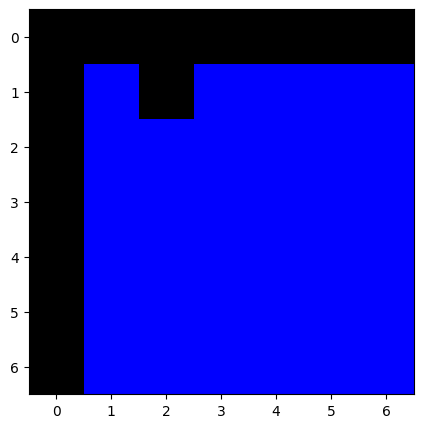

In [ ]:
from patchify import patchify, unpatchify

test_map = pd.read_csv('Dataset_test_map.csv')

test_hsi_cube = test_map.iloc[:, :-1].values

test_ground_truth = test_map.iloc[:, -1].values

test_hsi_cube=np.reshape(test_hsi_cube, (145, 145,200))
test_ground_truth=np.reshape(test_ground_truth, (145, 145))
test_hsi_cube=np.pad(test_hsi_cube,((1,1),(1,1),(0,0)),mode='constant', constant_values=0)
test_ground_truth=np.pad(test_ground_truth,((1,1),(1,1)),mode='constant', constant_values=0)
print(test_hsi_cube.shape,test_ground_truth.shape)



patches = patchify(test_hsi_cube, (7, 7, 200), step=7).reshape((-1,7, 7, 200))
patches_gt = patchify(test_ground_truth, (7, 7), step=7).reshape((-1,7, 7))

print("patches ",patches.shape,patches_gt.shape)
spectral.imshow(classes=patches_gt[0,:,:].astype(int), figsize=(5, 5))

In [ ]:
Y_pred_test = model.predict(patches[0,:,:,:].reshape((1,7, 7, 200)))
y_pred_test = np.argmax(Y_pred_test, axis=3)+1
print(y_pred_test)
y_pred_test.shape

1/1 [==============================] - 0s 383ms/step
[[[ 7  7  7  7  7  7  7]
  [ 7 12 13 12 12 12 12]
  [ 7  4  9  9  9  9  3]
  [ 7 11  9 11  9  9  3]
  [ 7  4  9  9  9  4  4]
  [ 7 11  9  9  9  9  4]
  [ 7  2  9 11  9  9 15]]]


(1, 7, 7)

ImageView object:
  Interpolation       :  <default>

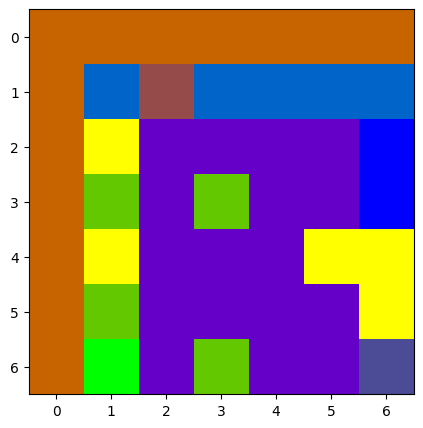

In [ ]:
spectral.imshow(classes=y_pred_test[0,:,:].astype(int), figsize=(5, 5))

In [ ]:
Y_pred_test = model.predict(patches)
y_pred_test = np.argmax(Y_pred_test, axis=3)+1
y_pred_test.shape

14/14 [==============================] - 0s 12ms/step


(441, 7, 7)

class_map  (145, 145)


ImageView object:
  Interpolation       :  <default>

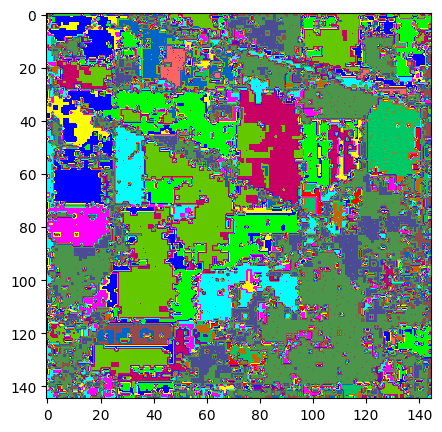

In [ ]:
class_map = unpatchify(y_pred_test.reshape((-1,21,7,7)), test_ground_truth.shape)
class_map_gt = unpatchify(patches_gt.reshape((-1,21,7,7)), test_ground_truth.shape)

class_map=class_map[1:-1,1:-1]
class_map_gt=class_map_gt[1:-1,1:-1]
print("class_map ",class_map.shape)
spectral.imshow(classes=class_map.astype(int), figsize=(5, 5),cmap='jet')


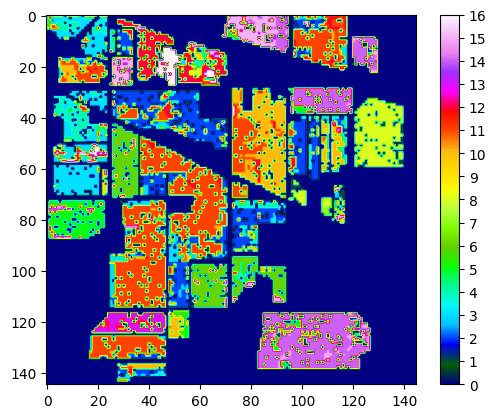

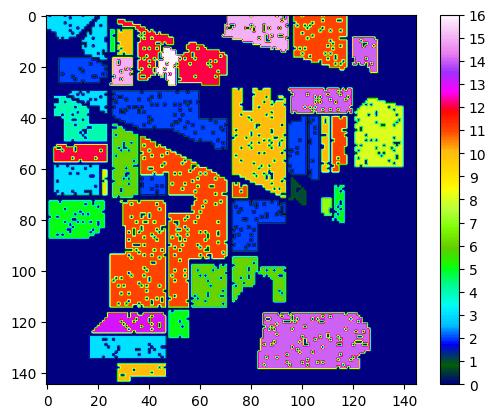

In [ ]:
# test_ground_truth = test_map.iloc[:, -1].values

# test_hsi_cube=np.reshape(test_hsi_cube, (145, 145,200))
# test_ground_truth=np.reshape(test_ground_truth, (145, 145))

class_map = class_map*(class_map_gt>0)
# fig, (ax1, ax2) = plt.subplots(1, 2)

plt.imshow(class_map.astype(int),cmap='gist_ncar')
plt.colorbar(ticks= range(0,17))

plt.show()
plt.imshow(class_map_gt.astype(int),cmap='gist_ncar')
plt.colorbar(ticks= range(0,17))
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# test_ground_truth = test_map.iloc[:, -1].values
# test_ground_truth=np.reshape(test_ground_truth, (-1, 1))
class_map2=class_map.reshape((-1))
class_map_gt2=class_map_gt.reshape((-1))
class_map2=class_map2[class_map_gt2>0]
class_map_gt2=class_map_gt2[class_map_gt2>0]

print(class_map2.shape,class_map_gt2.shape)



print(f'Accuracy: {accuracy_score(class_map2.astype(int), class_map_gt2.astype(int))*100}%')

(9225,) (9225,)
Accuracy: 67.69647696476964%


In [ ]:
model.save('my_model_old.h5')

In [ ]:
# 1. Install virtualenv utility
!pip install virtualenv

# 2. Create the virtual environment folder
!virtualenv my_env

# 3. Install TensorFlow 2.15 and matching Keras into the environment
!./my_env/bin/pip install "tensorflow==2.15.0" "keras==2.15.0"


created virtual environment CPython3.11.13.final.0-64-x86_64 in 433ms
  creator CPython3Posix(dest=/content/my_env, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.1.2, setuptools==83.0.0
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 57.3 MB/s  0:00:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 107.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 148.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.5 MB/s  0:00:00
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%%writefile convert_model.py
import tensorflow as tf
print("Using TensorFlow Version:", tf.__version__)

# Load your old model inside the Keras 2 environment
model = tf.keras.models.load_model('/content/drive/MyDrive/Bsc Thesis/Seminar 2 code/Dataset/my_model_old.h5')

# Strip out the configuration and export only the raw weights
model.save_weights('/content/drive/MyDrive/Bsc Thesis/Seminar 2 code/Dataset/my_model_old_weights.weights.h5')
print("Successfully exported model weights!")




Overwriting convert_model.py


In [ ]:
!./my_env/bin/python convert_model.py

2026-07-07 05:15:57.885073: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-07 05:15:57.885550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-07 05:15:57.887281: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-07 05:15:57.897374: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-07 05:15:58.790890: W tensorflow/comp

In [ ]:
import tensorflow as tf

# 1. Define your exact architecture here (Functional or Sequential)
def build_model():
    inputs = tf.keras.Input(shape=(...)) # Add your input shape
    # Add your layers here manually
    # Replace any previous TFOpLambda math operations with standard Lambda layers
    x = tf.keras.layers.Lambda(lambda t: t + 1)(inputs)
    outputs = tf.keras.layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)

model = build_model()

# 2. Load the freshly extracted weights
model.load_weights('/content/drive/MyDrive/Bsc Thesis/Seminar 2 code/Dataset/my_model_old_weights.weights.h5')

# 3. Save it natively in Keras 3 format so you never need this workaround again
model.save('my_model_old_modern.keras')

ValueError: Cannot convert 'Ellipsis' to a shape.

In [ ]:
!./my_env/bin/python convert_model.py

2026-07-07 04:56:35.040900: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-07 04:56:35.041166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-07 04:56:35.043714: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-07 04:56:35.052585: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-07 04:56:36.017776: W tensorflow/comp

In [ ]:
model.summary()

NameError: name 'model' is not defined

In [ ]:
import tensorflow as tf

# Force Keras 3 to use the old saving format
tf.keras.config.enable_unsafe_deserialization()

model = tf.keras.models.load_model('my_model_old.h5')


ValueError: Unknown layer: 'TFOpLambda'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model('my_model_old.h5')

# Rotation

In [ ]:
from patchify import patchify, unpatchify
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def rotation(k):


    test_map = pd.read_csv('Dataset_test_map.csv')

    test_hsi_cube = test_map.iloc[:, :-1].values

    test_ground_truth = test_map.iloc[:, -1].values

    test_hsi_cube=np.reshape(test_hsi_cube, (145, 145,200))
    test_ground_truth=np.reshape(test_ground_truth, (145, 145))
    test_hsi_cube=np.pad(test_hsi_cube,((1,1),(1,1),(0,0)),mode='constant', constant_values=0)
    test_ground_truth=np.pad(test_ground_truth,((1,1),(1,1)),mode='constant', constant_values=0)
    print(test_hsi_cube.shape,test_ground_truth.shape)



    patches = patchify(test_hsi_cube, (7, 7, 200), step=7).reshape((-1,7, 7, 200))
    patches_gt = patchify(test_ground_truth, (7, 7), step=7).reshape((-1,7, 7))

    print("patches ",patches.shape,patches_gt.shape)
    # spectral.imshow(classes=patches_gt[0,:,:].astype(int), figsize=(5, 5))

    patches = np.array([
        np.rot90(sample, k) for sample in patches
    ])

    patches_gt = np.array([
        np.rot90(sample, k) for sample in patches_gt
    ])

    Y_pred_test = model.predict(patches)
    y_pred_test = np.argmax(Y_pred_test, axis=3)+1
    y_pred_test.shape


    class_map = unpatchify(y_pred_test.reshape((-1,21,7,7)), test_ground_truth.shape)
    class_map_gt = unpatchify(patches_gt.reshape((-1,21,7,7)), test_ground_truth.shape)

    # class_map=class_map[1:-1,1:-1]
    # class_map_gt=class_map_gt[1:-1,1:-1]
    print("class_map ",class_map.shape)
    # spectral.imshow(classes=class_map.astype(int), figsize=(5, 5),cmap='jet')

    class_map = class_map*(class_map_gt>0)
    # fig, (ax1, ax2) = plt.subplots(1, 2)

    plt.imshow(class_map.astype(int),cmap='gist_ncar')
    plt.colorbar(ticks= range(0,17))

    plt.show()
    plt.imshow(class_map_gt.astype(int),cmap='gist_ncar')
    plt.colorbar(ticks= range(0,17))
    plt.show()


    # test_ground_truth = test_map.iloc[:, -1].values
    # test_ground_truth=np.reshape(test_ground_truth, (-1, 1))
    class_map2=class_map.reshape((-1))
    class_map_gt2=class_map_gt.reshape((-1))
    class_map2=class_map2[class_map_gt2>0]
    class_map_gt2=class_map_gt2[class_map_gt2>0]

    print(class_map2.shape,class_map_gt2.shape)



    print(f'Accuracy {k}: {accuracy_score(class_map2.astype(int), class_map_gt2.astype(int))*100}%')
    conf=confusion_matrix(class_map_gt2, class_map2)
    conf = np.mat(conf)
    OA = np.sum(np.trace(conf)) / np.sum(conf)
    Po = OA
    xsum = np.sum(conf, axis=1)
    ysum = np.sum(conf, axis=0)
    Pe = float(ysum*xsum)/(np.sum(conf)**2)
    Kappa = float((Po-Pe)/(1-Pe))

    list_diag = np.diag(conf)
    each_acc = np.nan_to_num(truediv(list_diag, ysum))
    average_acc = np.mean(each_acc)
    precision = np.nan_to_num(truediv(list_diag, xsum.T))
    average_precision = np.mean(precision)

    print(each_acc*100)
    print(average_acc)
    print(Kappa)

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 1s 39ms/step
class_map  (147, 147)


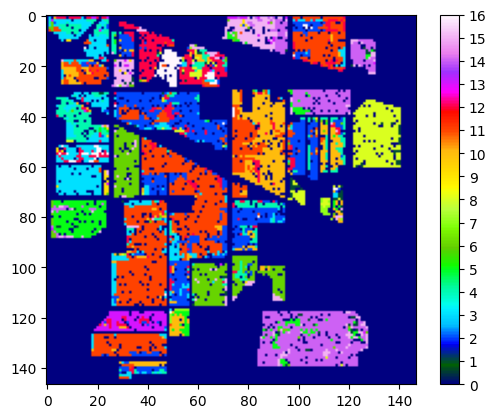

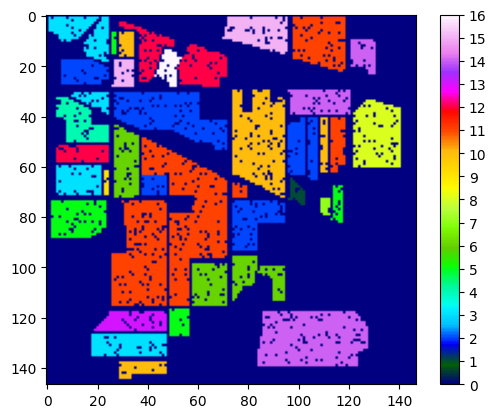

(9225,) (9225,)
Accuracy 0: 67.69647696476964%
[[12.12121212 65.94323873 49.49874687 30.55555556 73.31536388 90.86538462
  48.38709677 83.50305499 42.42424242 65.39473684 69.86692015 51.76908752
  81.96721311 91.17361785 56.23409669 58.57142857]]
0.6072443729391954
0.6340809353791365


/tmp/ipython-input-8-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(0)

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 1s 86ms/step
class_map  (147, 147)


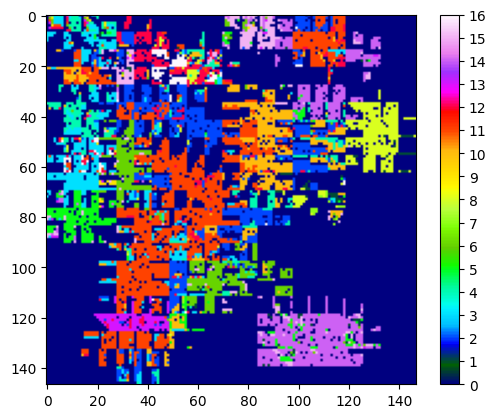

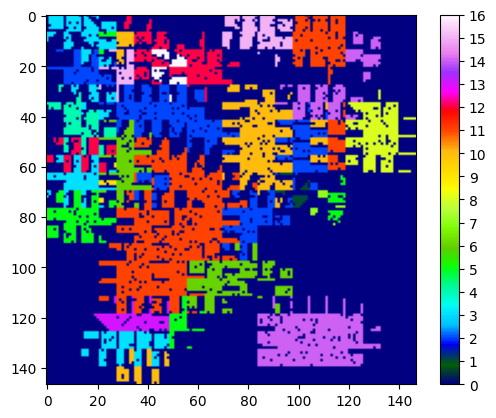

(9225,) (9225,)
Accuracy 1: 68.32520325203252%
[[15.30612245 67.17990276 50.79155673 29.58963283 74.54068241 89.20634921
  61.53846154 82.65306122 41.17647059 64.39393939 69.55113373 57.97101449
  84.29319372 90.9351145  55.94594595 60.74074074]]
0.6223833264143395
0.6405740734266308


/tmp/ipython-input-8-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(1)

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 1s 40ms/step
class_map  (147, 147)


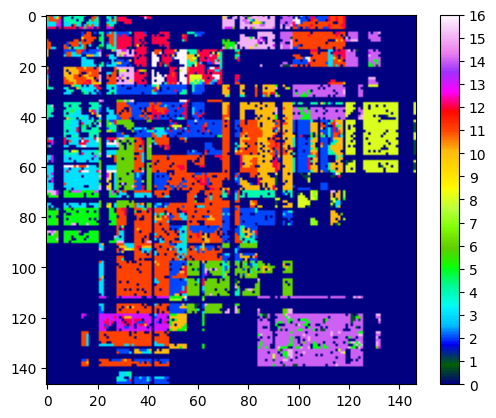

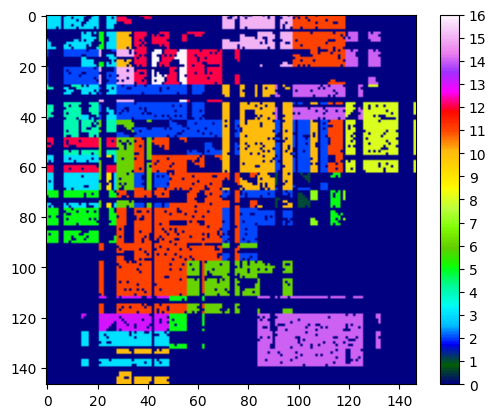

(9225,) (9225,)
Accuracy 2: 66.9159891598916%
[[12.62135922 65.70212766 43.8450899  28.69757174 70.05076142 92.22042139
  58.06451613 83.7398374  41.37931034 63.28626444 68.26347305 50.25996534
  76.96335079 93.17507418 62.53521127 62.90322581]]
0.608567225058871
0.6248652088559722


/tmp/ipython-input-8-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(2)

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 1s 46ms/step
class_map  (147, 147)


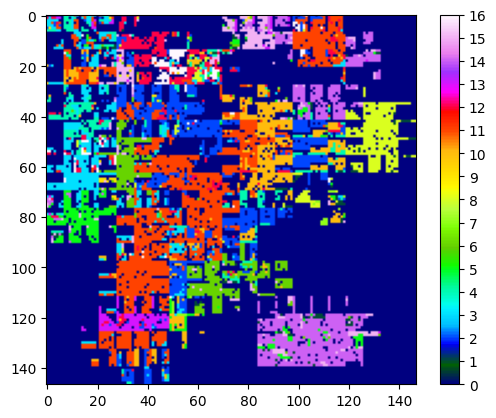

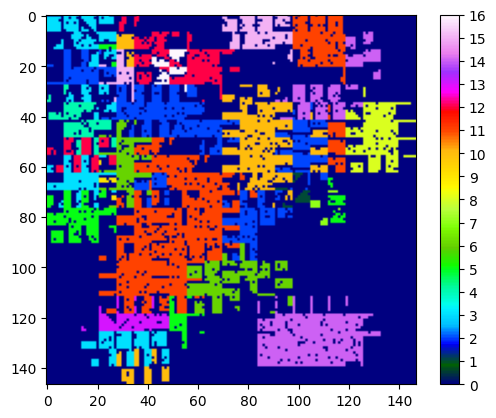

(9225,) (9225,)
Accuracy 3: 68.19512195121952%
[[ 9.4488189  68.83223684 50.34674064 30.71593533 74.43820225 92.91598023
  51.72413793 82.99595142 48.27586207 63.86010363 69.3786321  59.16473318
  78.5        91.15646259 52.60416667 50.625     ]]
0.6093643523508201
0.6387788036640754


/tmp/ipython-input-8-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(3)

# 90 rotation

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 0s 4ms/step


/usr/local/lib/python3.10/dist-packages/spectral/graphics/spypylab.py:796: UserWarning:

Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.



class_map  (147, 147)


ImageView object:
  Interpolation       :  <default>

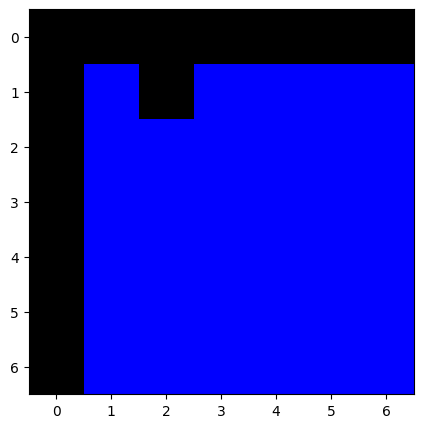

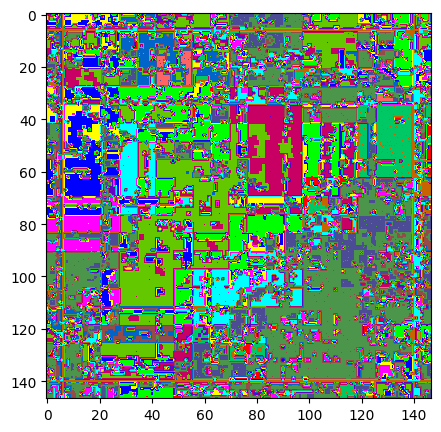

In [ ]:
from patchify import patchify, unpatchify

test_map = pd.read_csv('Dataset_test_map.csv')

test_hsi_cube = test_map.iloc[:, :-1].values

test_ground_truth = test_map.iloc[:, -1].values

test_hsi_cube=np.reshape(test_hsi_cube, (145, 145,200))
test_ground_truth=np.reshape(test_ground_truth, (145, 145))
test_hsi_cube=np.pad(test_hsi_cube,((1,1),(1,1),(0,0)),mode='constant', constant_values=0)
test_ground_truth=np.pad(test_ground_truth,((1,1),(1,1)),mode='constant', constant_values=0)
print(test_hsi_cube.shape,test_ground_truth.shape)



patches = patchify(test_hsi_cube, (7, 7, 200), step=7).reshape((-1,7, 7, 200))
patches_gt = patchify(test_ground_truth, (7, 7), step=7).reshape((-1,7, 7))

print("patches ",patches.shape,patches_gt.shape)
spectral.imshow(classes=patches_gt[0,:,:].astype(int), figsize=(5, 5))

patches = np.array([
    np.rot90(sample, 2) for sample in patches
])

patches_gt = np.array([
    np.rot90(sample, 2) for sample in patches_gt
])

Y_pred_test = model.predict(patches)
y_pred_test = np.argmax(Y_pred_test, axis=3)+1
y_pred_test.shape


class_map = unpatchify(y_pred_test.reshape((-1,21,7,7)), test_ground_truth.shape)
class_map_gt = unpatchify(patches_gt.reshape((-1,21,7,7)), test_ground_truth.shape)

# class_map=class_map[1:-1,1:-1]
# class_map_gt=class_map_gt[1:-1,1:-1]
print("class_map ",class_map.shape)
spectral.imshow(classes=class_map.astype(int), figsize=(5, 5),cmap='jet')




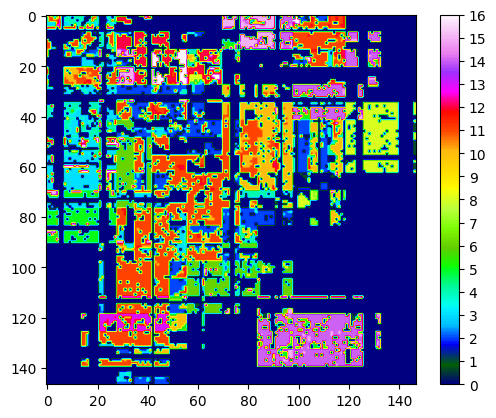

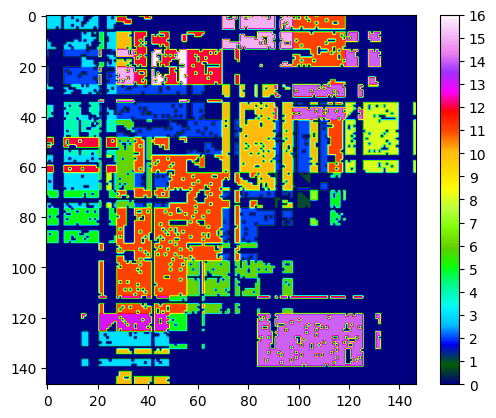

In [ ]:
class_map = class_map*(class_map_gt>0)
# fig, (ax1, ax2) = plt.subplots(1, 2)

plt.imshow(class_map.astype(int),cmap='gist_ncar')
plt.colorbar(ticks= range(0,17))

plt.show()
plt.imshow(class_map_gt.astype(int),cmap='gist_ncar')
plt.colorbar(ticks= range(0,17))
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# test_ground_truth = test_map.iloc[:, -1].values
# test_ground_truth=np.reshape(test_ground_truth, (-1, 1))
class_map2=class_map.reshape((-1))
class_map_gt2=class_map_gt.reshape((-1))
class_map2=class_map2[class_map_gt2>0]
class_map_gt2=class_map_gt2[class_map_gt2>0]

print(class_map2.shape,class_map_gt2.shape)



print(f'Accuracy {180}: {accuracy_score(class_map2.astype(int), class_map_gt2.astype(int))*100}%')

(9225,) (9225,)
Accuracy 180: 66.9159891598916%


In [ ]:
 from sklearn.metrics import confusion_matrix
 conf=confusion_matrix(class_map_gt2, class_map2)

In [ ]:
confusion_matrix = np.mat(conf)
OA = np.sum(np.trace(confusion_matrix)) / np.sum(confusion_matrix)
Po = OA
xsum = np.sum(confusion_matrix, axis=1)
ysum = np.sum(confusion_matrix, axis=0)
Pe = float(ysum*xsum)/(np.sum(confusion_matrix)**2)
Kappa = float((Po-Pe)/(1-Pe))

list_diag = np.diag(confusion_matrix)
each_acc = np.nan_to_num(truediv(list_diag, ysum))
average_acc = np.mean(each_acc)
precision = np.nan_to_num(truediv(list_diag, xsum.T))
average_precision = np.mean(precision)

print(each_acc)


[[0.12621359 0.65702128 0.4384509  0.28697572 0.70050761 0.92220421
  0.58064516 0.83739837 0.4137931  0.63286264 0.68263473 0.50259965
  0.76963351 0.93175074 0.62535211 0.62903226]]


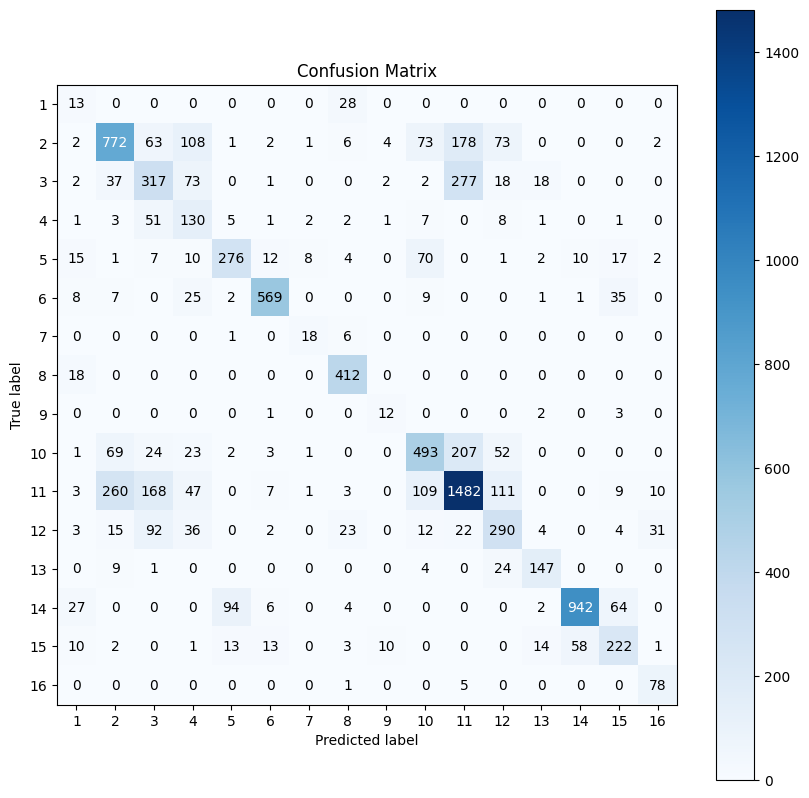

In [ ]:
! pip install -q scikit-plot

import scikitplot as skplt

skplt.metrics.plot_confusion_matrix(
    class_map_gt2,
    class_map2,
    figsize=(10,10));

In [ ]:
x = [1, 3, 2, 5]
x = np.reshape(x,(2,2))
y = np.pad(x, (0,1), 'edge')
y

array([[1, 3, 3],
       [2, 5, 5],
       [2, 5, 5]])

In [ ]:
array = np.array([
    [[
        [1, 2, 3],
        [4, 5, 6],
    ],
    [
        [7, 8, 9],
        [10, 11, 12],
    ]],
    [[
        [1, 2, 3],
        [4, 5, 6],
    ],
    [
        [7, 8, 9],
        [10, 11, 12],
    ]],
    [[
        [1, 2, 3],
        [4, 5, 6],
    ],
    [
        [7, 8, 9],
        [10, 11, 12],
    ]]
])

print(array.shape)

rotated_array = np.array([
    np.rot90(sample, 1) for sample in array
])

(3, 2, 2, 3)


In [ ]:
from patchify import patchify, unpatchify
from sklearn.metrics import confusion_matrix, accuracy_score

# ---------------------------------------------------------------------------
# L2L-Pix: Unlabeled-to-Labeled Pixel Replacement (Algorithm 1 in the paper)
#   Step 1: among the ANNOTATED positions of the patch (label != 0, class id is
#           never read), find the most frequent spectral vector p*.     Eq.(1)-(2)
#   Step 2: p_hat = argmin_{p in S \ {p*}} SAM(p*, p), where S holds the spectral
#           vectors of all test pixels (spectra only, no labels).       Eq.(3)-(4)
#   Step 3: if the patch has no annotated pixel, p_hat = random sample of S.
#   Every unlabeled pixel of the patch is replaced by p_hat.
# ---------------------------------------------------------------------------

# Load the unpadded test image once
test_map_df = pd.read_csv('Dataset_test_map.csv')
test_hsi_cube_original_reshaped = test_map_df.iloc[:, :-1].values.reshape((145, 145, 200)).astype(np.float64)
test_ground_truth_original = test_map_df.iloc[:, -1].values.reshape((145, 145))

# S: spectral vectors of all test pixels (labels are only used to know WHICH
# pixels belong to the test set, never their class)
S = test_hsi_cube_original_reshaped[test_ground_truth_original > 0]          # (|S|, 200)
S_unit = S / (np.linalg.norm(S, axis=1, keepdims=True) + 1e-12)

class_pixel_lookup = None   # kept only so the existing rotation(...) calls still work; not used


def sam_nearest(p_star):
    """Step 2: pixel in S \\ {p*} with the smallest spectral angle to p*."""
    cos = S_unit @ (p_star / (np.linalg.norm(p_star) + 1e-12))
    cos[np.all(S == p_star, axis=1)] = -np.inf       # exclude p* itself
    return S[np.argmax(cos)]                          # min arccos(.) == max cosine


def l2l_pix(patches, patches_gt, rng):
    """Apply L2L-Pix to every test patch. patches: (N,7,7,B), patches_gt: (N,7,7)."""
    out = patches.copy()
    n_fallback = 0
    for i in range(patches.shape[0]):
        unlabeled = patches_gt[i] == 0
        if not unlabeled.any():
            continue
        annotated = ~unlabeled
        if annotated.any():
            # Step 1: most frequent spectral vector among annotated positions
            vals, counts = np.unique(patches[i][annotated], axis=0, return_counts=True)
            p_star = vals[np.argmax(counts)]
            # Step 2: SAM-nearest test pixel
            p_hat = sam_nearest(p_star)
        else:
            # Step 3: fallback random replacement
            p_hat = S[rng.integers(len(S))]
            n_fallback += 1
        out[i][unlabeled] = p_hat
    print(f'L2L-Pix: {int((patches_gt == 0).sum())} unlabeled pixels replaced, '
          f'{n_fallback} patches used the random fallback')
    return out


def rotation(k, m=0, class_pixel_lookup=None, test_hsi_cube_original_reshaped=None, seed=0):
    rng = np.random.default_rng(seed)

    test_hsi_cube = np.pad(test_hsi_cube_original_reshaped_global, ((1, 1), (1, 1), (0, 0)),
                           mode='constant', constant_values=0)
    test_ground_truth = np.pad(test_ground_truth_original, ((1, 1), (1, 1)),
                               mode='constant', constant_values=0)
    print(test_hsi_cube.shape, test_ground_truth.shape)

    patches = patchify(test_hsi_cube, (7, 7, 200), step=7).reshape((-1, 7, 7, 200))
    patches_gt = patchify(test_ground_truth, (7, 7), step=7).reshape((-1, 7, 7))
    print("patches ", patches.shape, patches_gt.shape)

    # L2L-Pix is applied to each cropped test patch before inference (Fig. 2)
    patches = l2l_pix(patches, patches_gt, rng)

    # Patch rotation for the rotation experiments (Tables II and V)
    patches = np.array([np.rot90(sample, k) for sample in patches])
    patches_gt = np.array([np.rot90(sample, k) for sample in patches_gt])

    Y_pred_test = model.predict(patches)
    y_pred_test = np.argmax(Y_pred_test, axis=3) + 1

    class_map = unpatchify(y_pred_test.reshape((-1, 21, 7, 7)), test_ground_truth.shape)
    class_map_gt = unpatchify(patches_gt.reshape((-1, 21, 7, 7)), test_ground_truth.shape)
    print("class_map ", class_map.shape)

    class_map = class_map * (class_map_gt > 0)

    plt.imshow(class_map.astype(int), cmap='gist_ncar', vmin=0, vmax=16)
    plt.colorbar(ticks=range(0, 17))
    plt.title(f'L2L-Pix prediction (rotation k={k})')
    plt.show()
    plt.imshow(class_map_gt.astype(int), cmap='gist_ncar', vmin=0, vmax=16)
    plt.colorbar(ticks=range(0, 17))
    plt.title('Ground truth')
    plt.show()

    class_map2 = class_map.reshape(-1)
    class_map_gt2 = class_map_gt.reshape(-1)
    keep = class_map_gt2 > 0
    y_pred, y_true = class_map2[keep].astype(int), class_map_gt2[keep].astype(int)
    print(y_pred.shape, y_true.shape)

    # ----- metrics: OA, class-wise accuracy, AA, Kappa -----
    conf = confusion_matrix(y_true, y_pred, labels=np.arange(1, 17))   # rows = true class
    N = conf.sum()
    OA = np.trace(conf) / N
    row_sum = conf.sum(axis=1)          # true pixels per class
    col_sum = conf.sum(axis=0)          # predicted pixels per class
    Pe = np.sum(row_sum * col_sum) / N**2
    Kappa = (OA - Pe) / (1 - Pe)
    each_acc = np.nan_to_num(np.diag(conf) / row_sum)   # producer's (class-wise) accuracy
    AA = np.mean(each_acc)

    print(f'Accuracy {k}: {accuracy_score(y_true, y_pred)*100}%')
    print('Class-wise accuracy (%):', np.round(each_acc * 100, 2))
    print('OA   :', round(OA * 100, 2))
    print('AA   :', round(AA * 100, 2))
    print('Kappa:', round(Kappa * 100, 2))
    return OA, AA, Kappa, each_acc


test_hsi_cube_original_reshaped_global = test_hsi_cube_original_reshaped


In [ ]:
rotation(0, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)

In [ ]:
rotation(1, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)

In [ ]:
rotation(2, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)

In [ ]:
rotation(3, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model('my_model.h5')

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 1s 43ms/step
class_map  (147, 147)


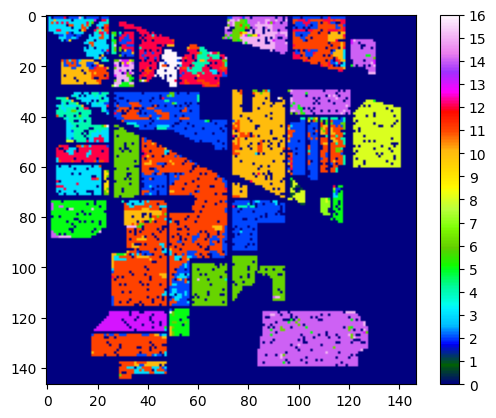

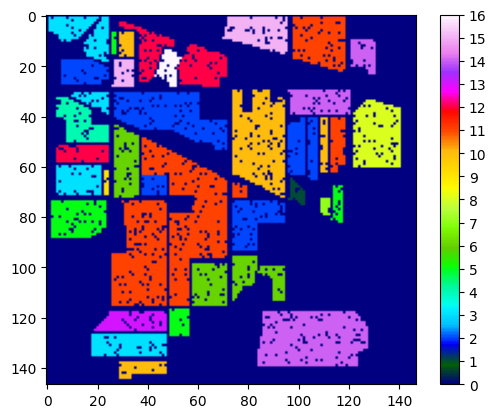

(9225,) (9225,)
Accuracy 0: 76.43360433604336%
[[92.85714286 72.11538462 63.86138614 47.94007491 87.70301624 83.80462725
  84.61538462 93.05856833 52.17391304 67.22866175 73.36448598 73.97260274
  88.83495146 90.237691   73.0964467  91.86046512]]
0.7729530017136157
0.7314060480852033


/tmp/ipython-input-6-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(0)

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 1s 47ms/step
class_map  (147, 147)


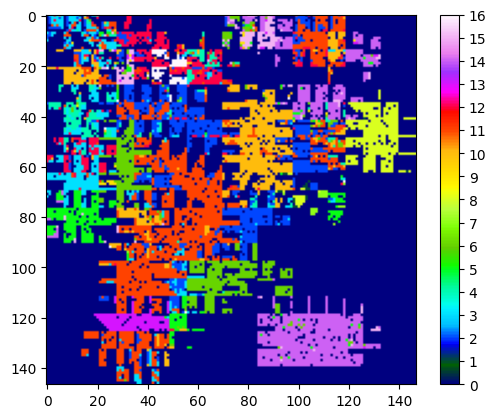

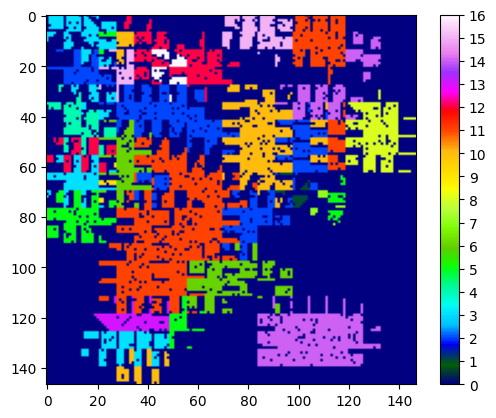

(9225,) (9225,)
Accuracy 1: 75.88075880758808%
[[88.88888889 73.20846906 59.05383361 46.49446494 88.20754717 83.26947637
  88.46153846 94.4812362  41.66666667 64.86486486 72.98150654 73.4939759
  91.04477612 90.17781541 75.12437811 89.77272727]]
0.7632451034932911
0.7249033739959112


/tmp/ipython-input-6-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(1)

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 0s 23ms/step
class_map  (147, 147)


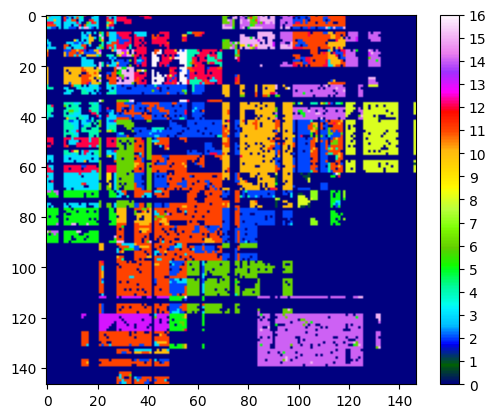

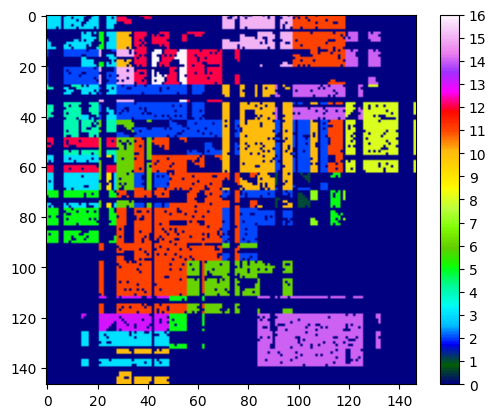

(9225,) (9225,)
Accuracy 2: 77.19241192411924%
[[85.71428571 73.58916479 64.86042693 50.3968254  89.97613365 82.76299113
  88.46153846 94.4812362  47.61904762 67.8343949  73.25102881 74.90039841
  90.59405941 91.46757679 75.34883721 90.69767442]]
0.7762222623952304
0.739845654944334


/tmp/ipython-input-6-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(2)

(147, 147, 200) (147, 147)
patches  (441, 7, 7, 200) (441, 7, 7)
14/14 [==============================] - 1s 42ms/step
class_map  (147, 147)


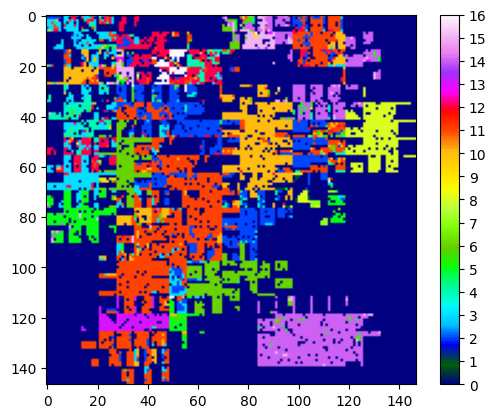

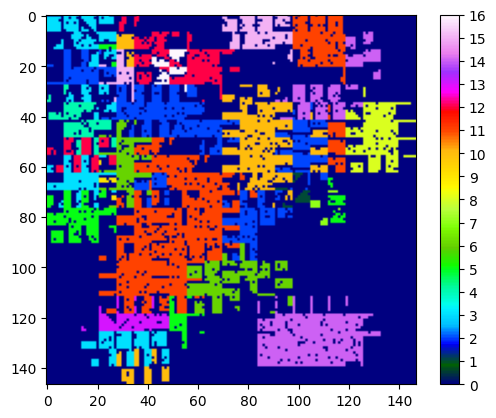

(9225,) (9225,)
Accuracy 3: 76.24932249322494%
[[83.33333333 75.43103448 61.01694915 45.83333333 87.35632184 83.97932817
  81.48148148 93.66812227 57.89473684 66.56378601 72.31663685 71.4559387
  91.5        90.88607595 76.41025641 89.65517241]]
0.7679890670195235
0.7291888501986415


/tmp/ipython-input-6-3295479211.py:78: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [ ]:
rotation(3)

In [ ]:
rotation(0, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)

In [ ]:
rotation(1, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)

In [ ]:
rotation(2, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)

In [ ]:
rotation(3, 0, class_pixel_lookup, test_hsi_cube_original_reshaped)